In [14]:
def denormalize_image(tensor_img):
    """
    Convert normalized tensor image back to displayable image.
    """

    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    image = tensor_img.cpu() * std + mean
    image = torch.clamp(image, 0, 1)

    return image

In [16]:
class_names = test_dataset.classes

print("Number of test images:", len(test_dataset))
print("Classes:", class_names)

Number of test images: 10000
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [17]:
misclassified_samples = []

model.eval()

with torch.no_grad():
    for batch_idx, (images, labels) in enumerate(test_loader):
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        probabilities = torch.softmax(outputs, dim=1)
        confidence_scores, predictions = torch.max(probabilities, dim=1)

        for i in range(images.size(0)):
            true_label = labels[i].item()
            predicted_label = predictions[i].item()
            confidence = confidence_scores[i].item()

            if predicted_label != true_label:
                misclassified_samples.append({
                    "image_tensor": images[i].cpu(),
                    "true_label_id": true_label,
                    "predicted_label_id": predicted_label,
                    "true_label": class_names[true_label],
                    "predicted_label": class_names[predicted_label],
                    "confidence": confidence,
                    "batch_index": batch_idx,
                    "sample_index": i
                })

print("Total misclassified samples:", len(misclassified_samples))

Total misclassified samples: 1995


In [19]:
import pandas as pd

misclassified_df = pd.DataFrame([
    {
        "true_label": sample["true_label"],
        "predicted_label": sample["predicted_label"],
        "confidence": sample["confidence"],
        "batch_index": sample["batch_index"],
        "sample_index": sample["sample_index"]
    }
    for sample in misclassified_samples
])

misclassified_df.head()

,true_label,predicted_label,confidence,batch_index,sample_index
0,automobile,truck,0.740866,0,6
1,automobile,truck,0.548540,0,9
2,bird,cat,0.276747,0,25
3,deer,cat,0.427548,0,26
4,automobile,truck,0.693406,1,5


In [21]:
import os

os.makedirs("outputs", exist_ok=True)

csv_path = "outputs/misclassified_report.csv"

misclassified_df.to_csv(csv_path, index=False)

print("CSV report saved at:", csv_path)

CSV report saved at: outputs/misclassified_report.csv


In [22]:
top_wrong_predictions = misclassified_df.sort_values(
    by="confidence",
    ascending=False
)

top_wrong_predictions.head(10)

,true_label,predicted_label,confidence,batch_index,sample_index
950,airplane,ship,0.999963,149,16
504,airplane,ship,0.998617,77,9
1167,automobile,truck,0.997146,183,26
726,frog,bird,0.996920,112,31
1522,bird,deer,0.996775,237,6
1905,cat,frog,0.996388,296,25
1093,airplane,ship,0.995459,172,12
694,deer,bird,0.994828,107,19
819,dog,cat,0.994824,126,19
239,truck,automobile,0.994549,37,15


In [23]:
import matplotlib.pyplot as plt

In [24]:
def show_misclassified_samples(samples, num_images=12):
    """
    Show misclassified image samples.
    """

    num_images = min(num_images, len(samples))

    plt.figure(figsize=(15, 10))

    for idx in range(num_images):
        sample = samples[idx]

        image = denormalize_image(sample["image_tensor"])
        image = image.permute(1, 2, 0)

        true_label = sample["true_label"]
        predicted_label = sample["predicted_label"]
        confidence = sample["confidence"]

        plt.subplot(3, 4, idx + 1)
        plt.imshow(image)
        plt.axis("off")
        plt.title(
            f"True: {true_label}\nPred: {predicted_label}\nConf: {confidence:.2f}",
            fontsize=10
        )

    plt.tight_layout()
    plt.show()

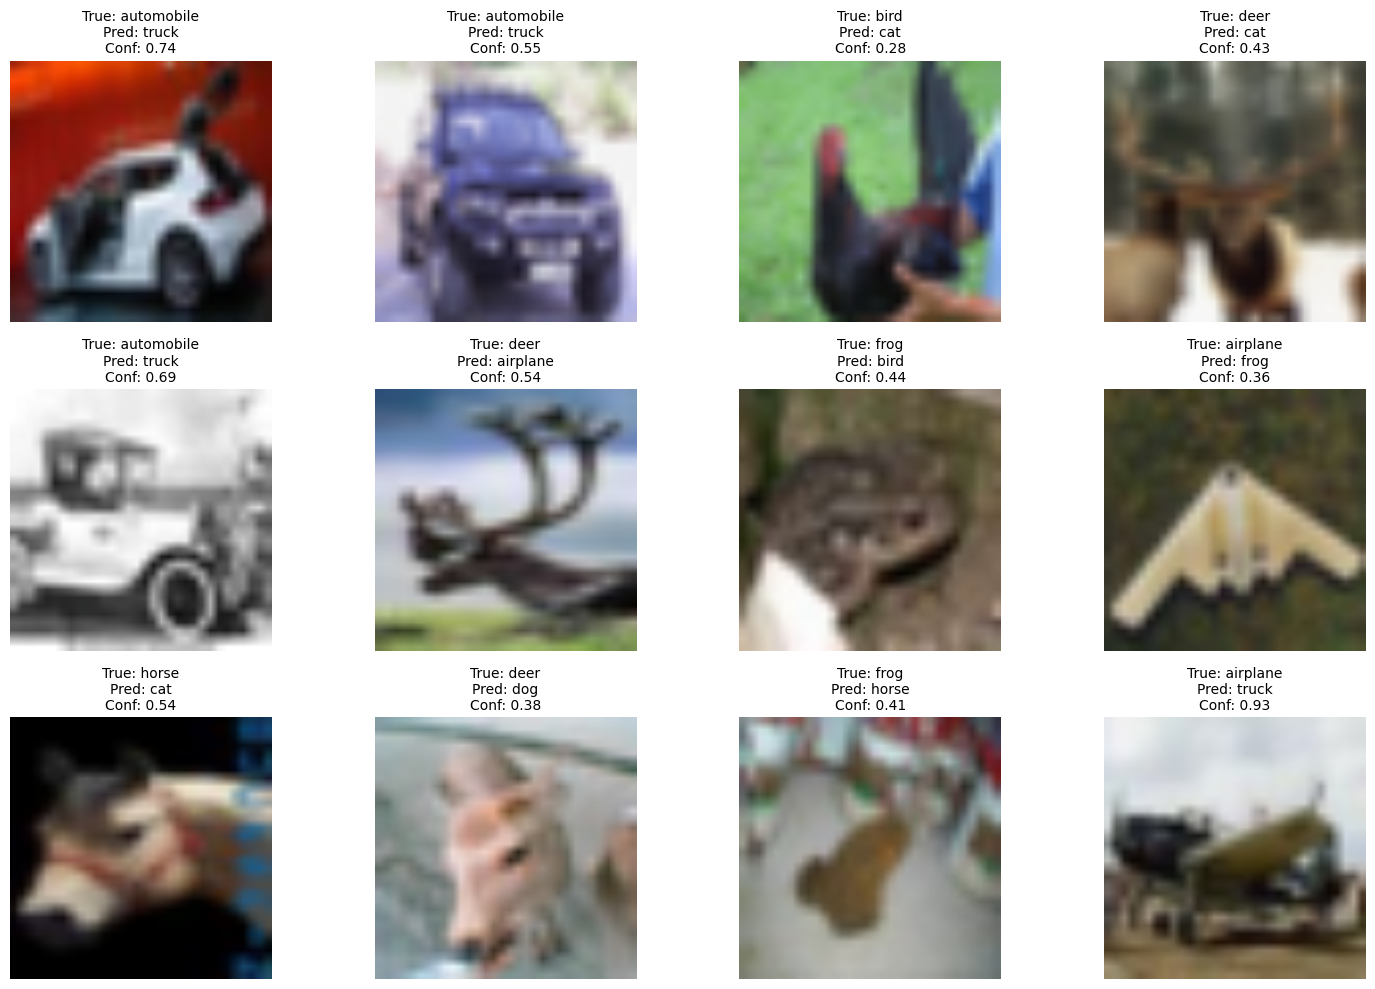

In [25]:
show_misclassified_samples(
    misclassified_samples,
    num_images=12
)

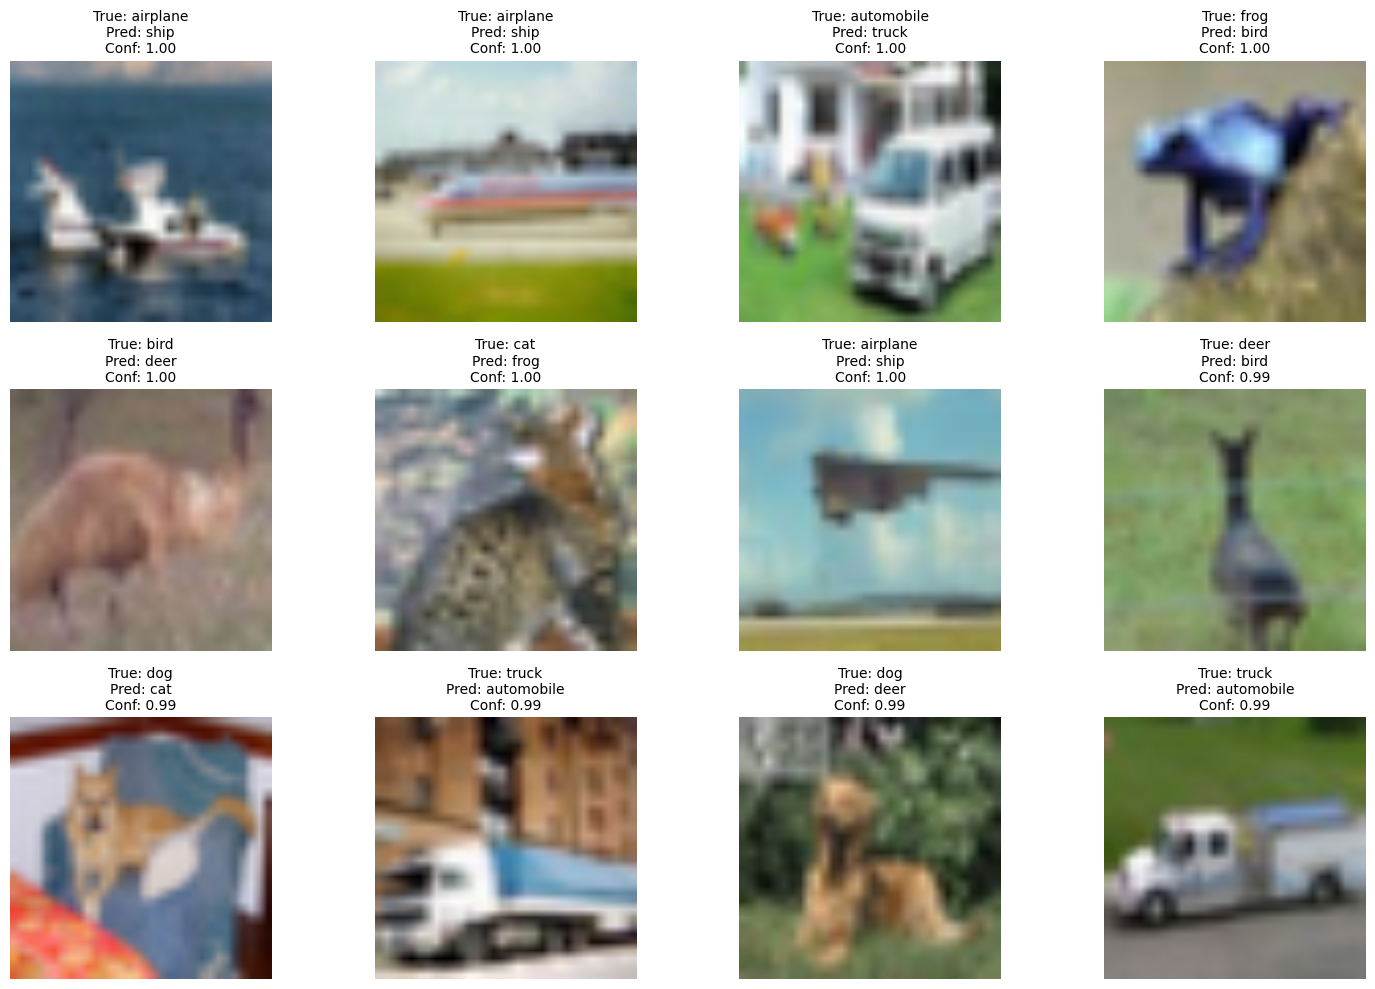

In [26]:
high_confidence_wrong = sorted(
    misclassified_samples,
    key=lambda x: x["confidence"],
    reverse=True
)

show_misclassified_samples(
    high_confidence_wrong,
    num_images=12
)

In [27]:
output_dir = "outputs/misclassified_images"
os.makedirs(output_dir, exist_ok=True)

for idx, sample in enumerate(misclassified_samples):
    image = denormalize_image(sample["image_tensor"])
    image = image.permute(1, 2, 0).numpy()

    true_label = sample["true_label"]
    predicted_label = sample["predicted_label"]
    confidence = sample["confidence"]

    save_path = os.path.join(
        output_dir,
        f"{idx}_true_{true_label}_pred_{predicted_label}_conf_{confidence:.2f}.png"
    )

    plt.imsave(save_path, image)

print("Misclassified images saved at:", output_dir)

Misclassified images saved at: outputs/misclassified_images


In [28]:
error_count = misclassified_df.groupby(
    ["true_label", "predicted_label"]
).size().reset_index(name="count")

error_count = error_count.sort_values(
    by="count",
    ascending=False
)

error_count.head(10)

,true_label,predicted_label,count
46,dog,cat,128
7,airplane,ship,111
37,deer,bird,99
31,cat,dog,88
41,deer,horse,88
17,automobile,truck,73
49,dog,horse,70
29,cat,bird,62
32,cat,frog,59
54,frog,bird,57


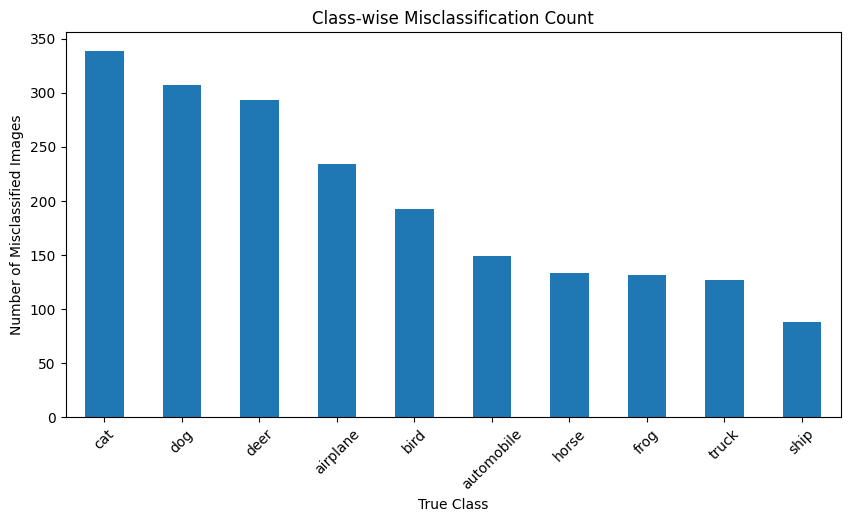

In [29]:
class_error_count = misclassified_df["true_label"].value_counts()

plt.figure(figsize=(10, 5))
class_error_count.plot(kind="bar")

plt.xlabel("True Class")
plt.ylabel("Number of Misclassified Images")
plt.title("Class-wise Misclassification Count")
plt.xticks(rotation=45)
plt.show()